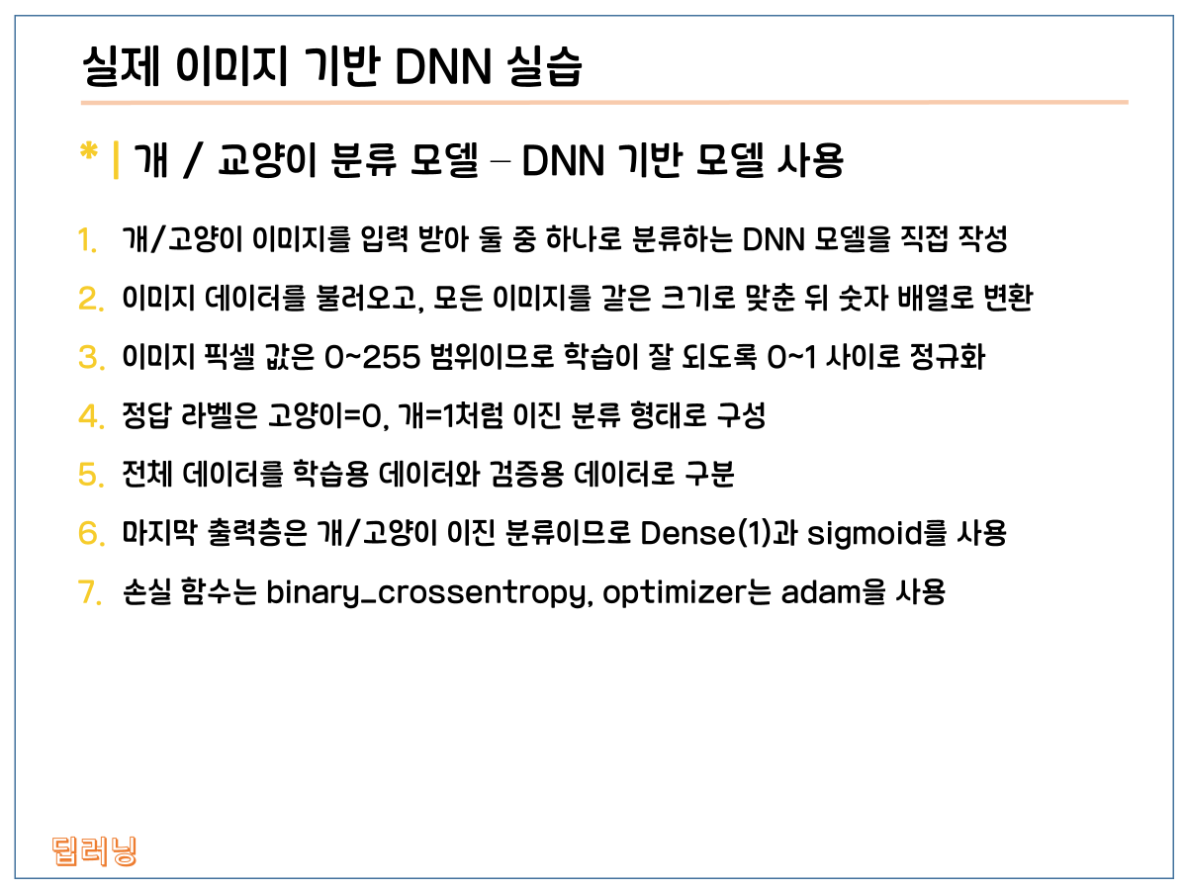

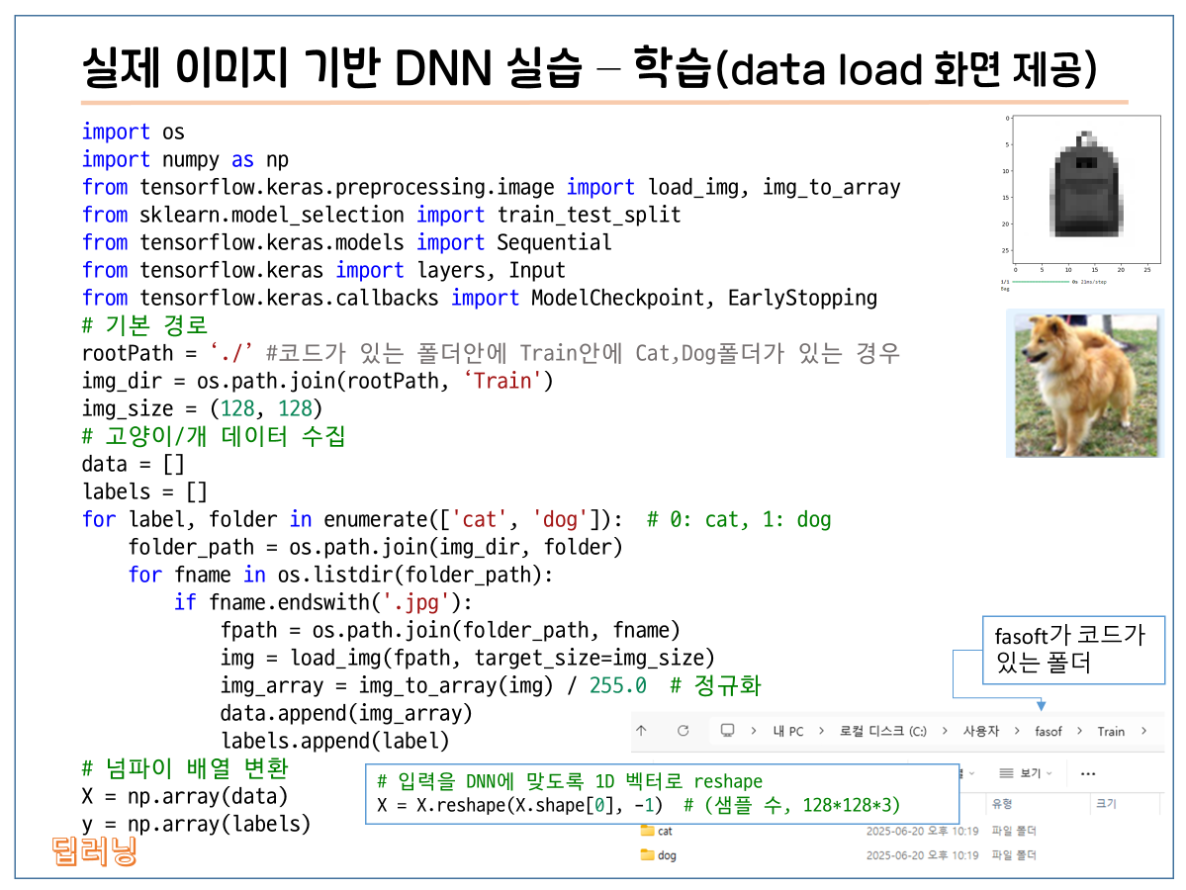

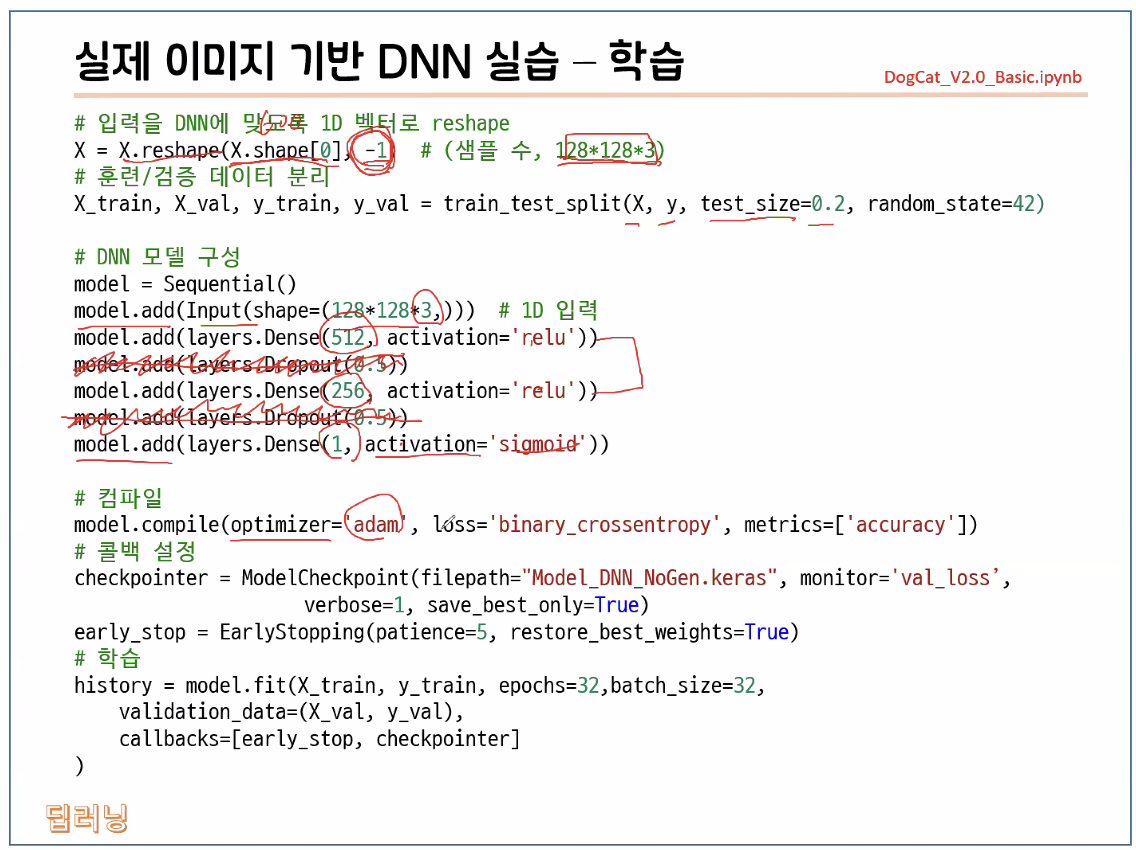

이미지 데이터: (2000, 128, 128, 3)
정답 라벨: (2000,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,299,905 (24.03 MB)

 Trainable params: 6,299,905 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7081 - loss: 2.6958 - val_accuracy: 0.9050 - val_loss: 0.2298
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8844 - loss: 0.2881 - val_accuracy: 0.9000 - val_loss: 0.2146
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8975 - loss: 0.2660 - val_accuracy: 0.9125 - val_loss: 0.2294
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8931 - loss: 0.2606 - val_accuracy: 0.8800 - val_loss: 0.2874
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9162 - loss: 0.2014 - val_accuracy: 0.9525 - val_loss: 0.1581
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8850 - loss: 0.3723 - val_accuracy: 0.7300 - val_loss: 1.2817
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8594 - loss: 0.4876 - val_accuracy: 0.9325 - val_loss: 0.1739
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8950 - loss: 0.3045 - val_accuracy: 0.9325 - v

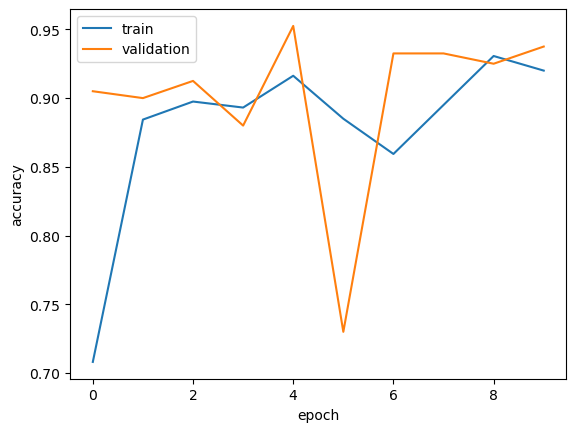

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, Input

# 1. 이미지 데이터 불러오기
rootPath = './'
img_dir = os.path.join(rootPath, 'Train')
img_size = (128, 128)
class_names = ['cat', 'dog']  # cat=0, dog=1

data = []
labels = []

for label, folder in enumerate(class_names):
    folder_path = os.path.join(img_dir, folder)

    for fname in os.listdir(folder_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            fpath = os.path.join(folder_path, fname)
            img = load_img(fpath, target_size=img_size)
            img_array = img_to_array(img) / 255.0  # 정규화

            data.append(img_array)
            labels.append(label)

X = np.array(data)
y = np.array(labels)

print('이미지 데이터:', X.shape)
print('정답 라벨:', y.shape)

# 2. DNN 입력에 맞게 1D 벡터로 변환
X = X.reshape(X.shape[0], -1)

# 3. 학습용 / 검증용 데이터 분리
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. DNN 모델 만들기
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # 이진 분류
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# 5. 모델 학습
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

# 6. 검증 데이터 평가
loss, accuracy = model.evaluate(X_val, y_val)
print('검증 정확도:', accuracy)

# 7. 학습 결과 그래프
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()


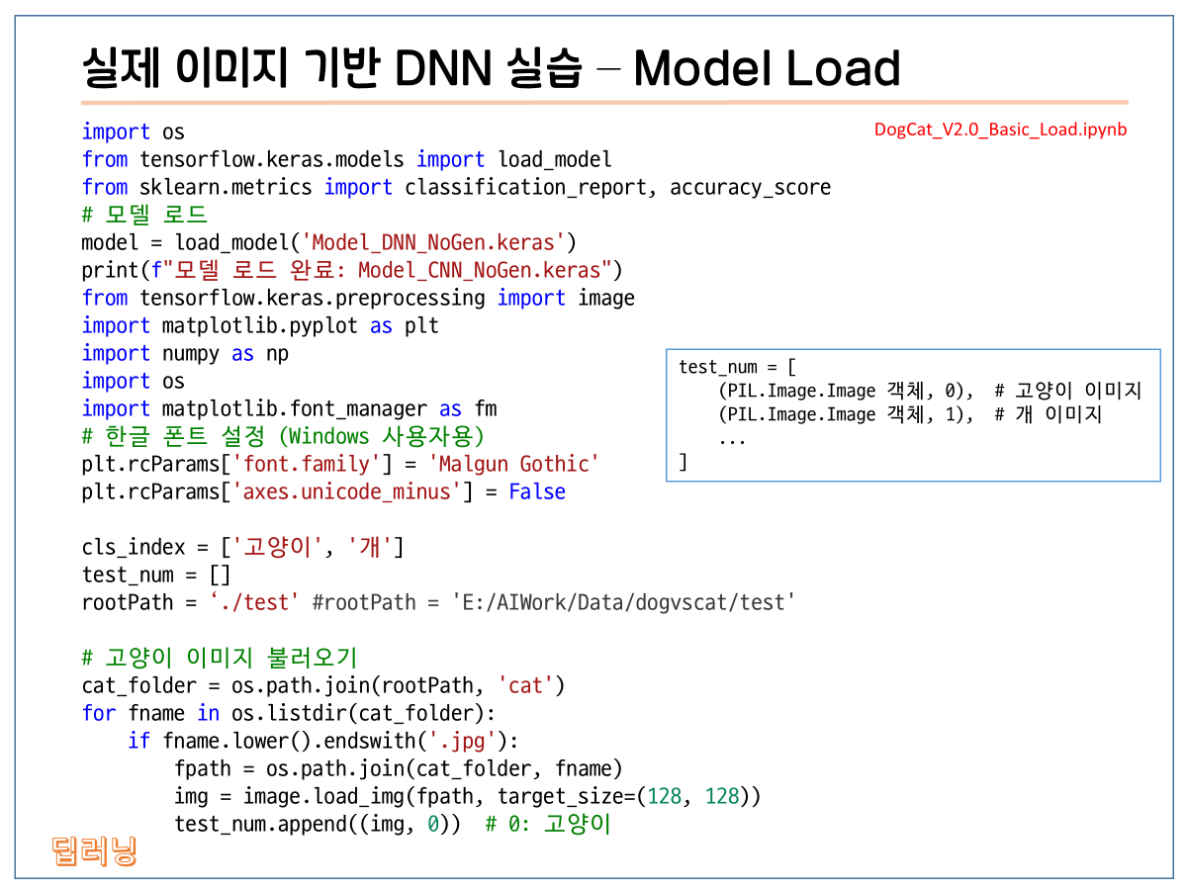

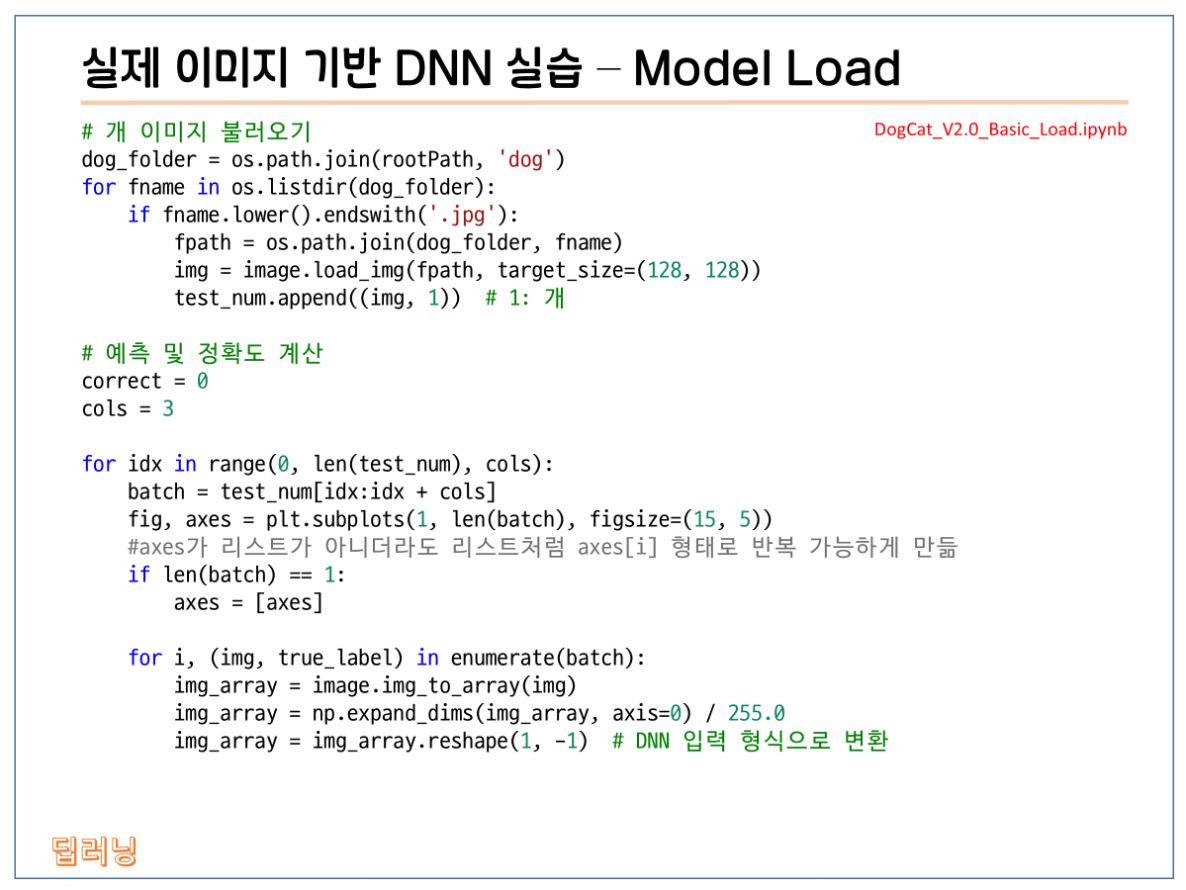

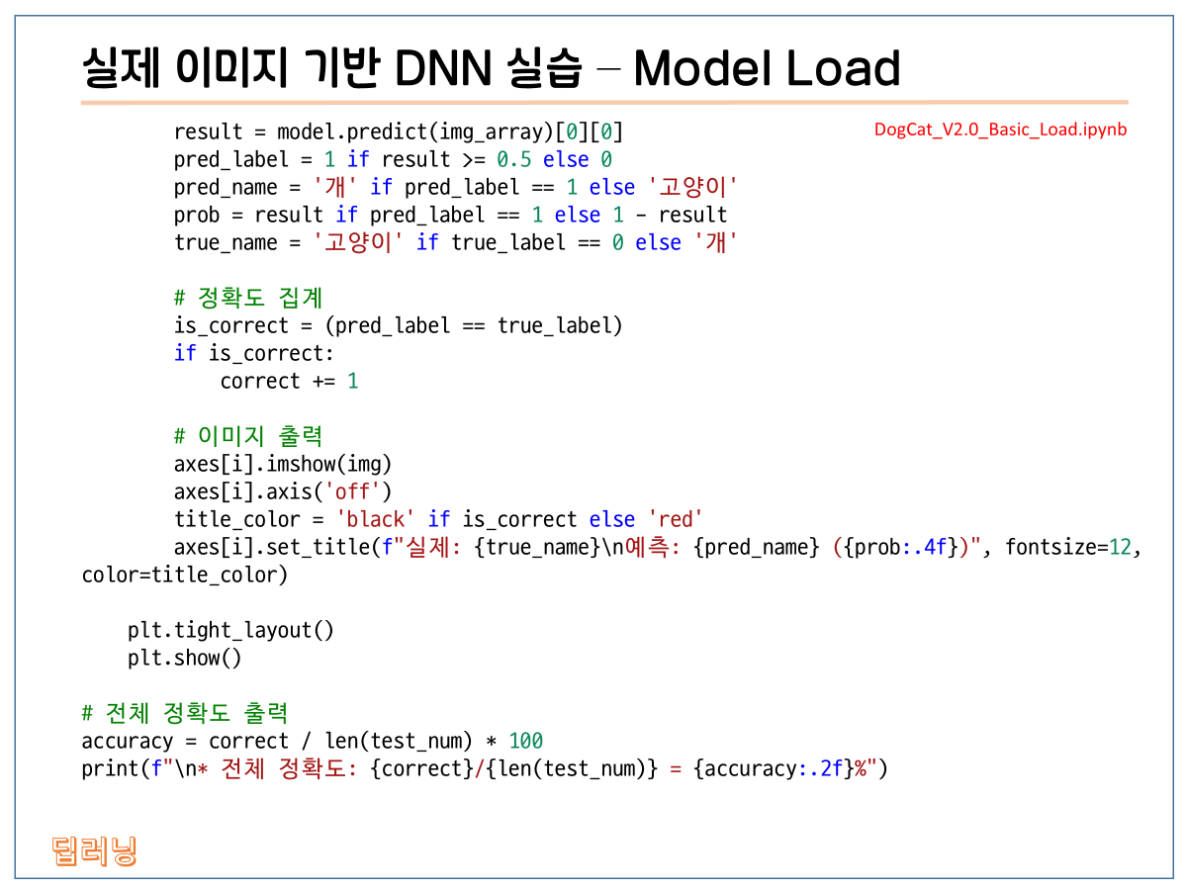

모델 로드 완료: Model_CNN_NoGen.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


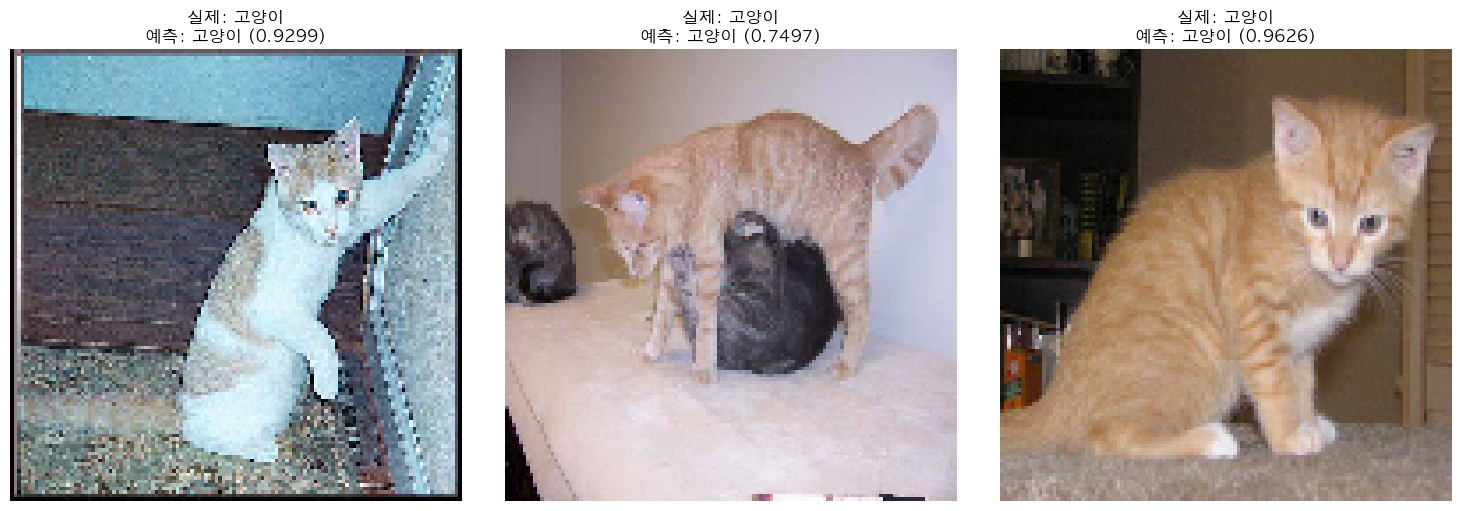

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


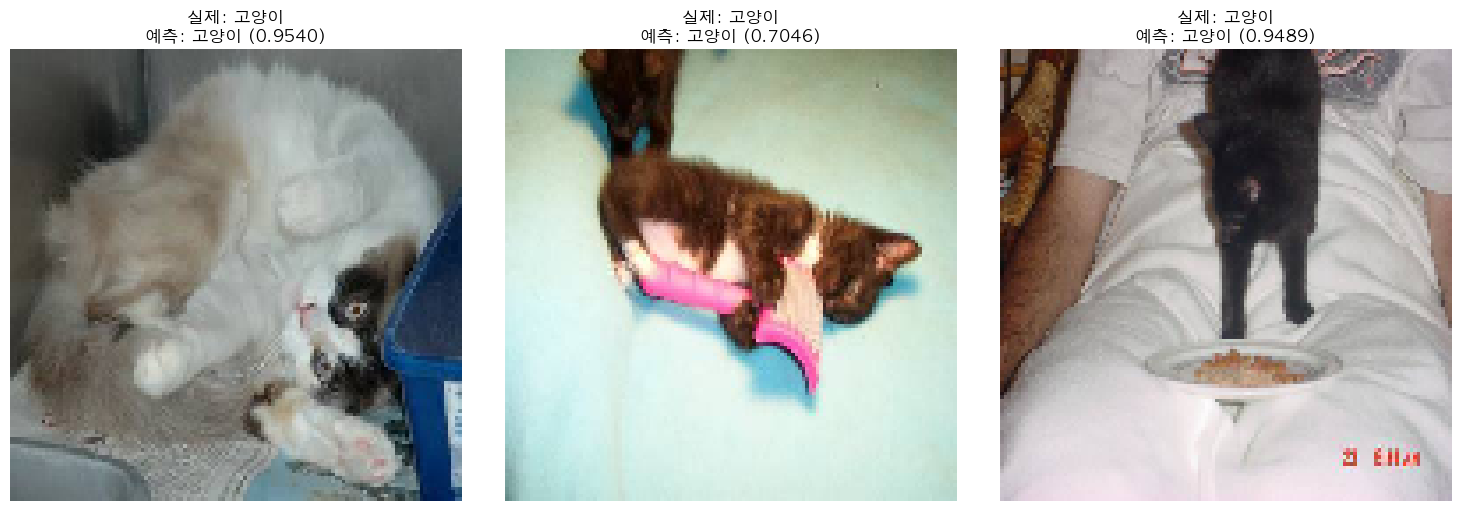

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


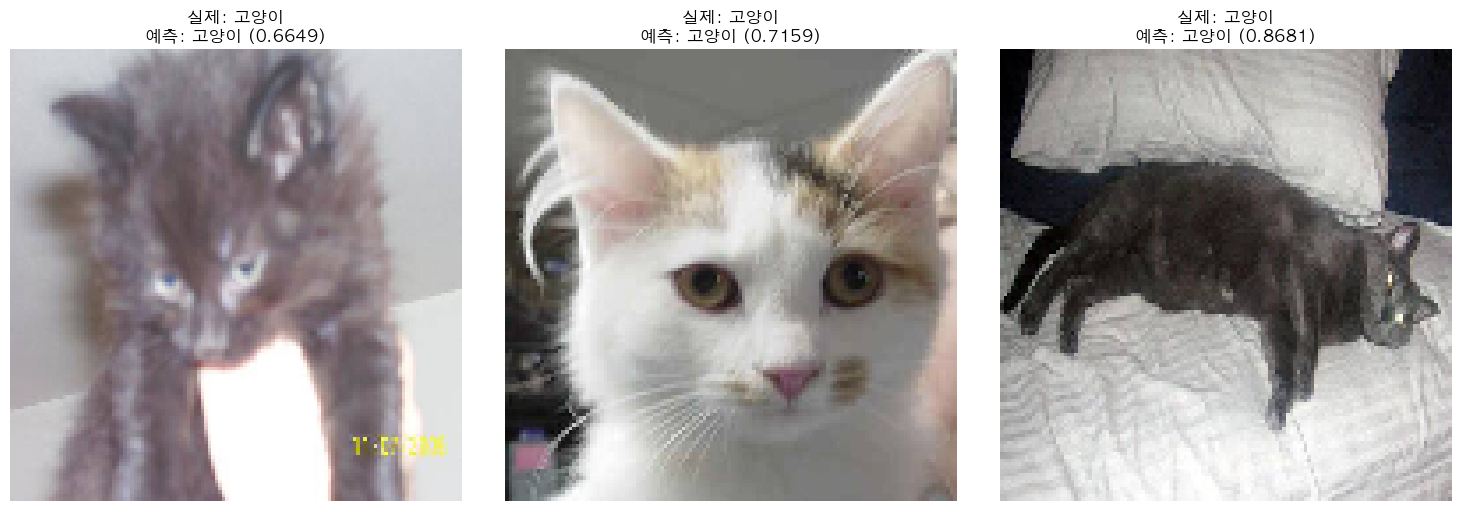

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


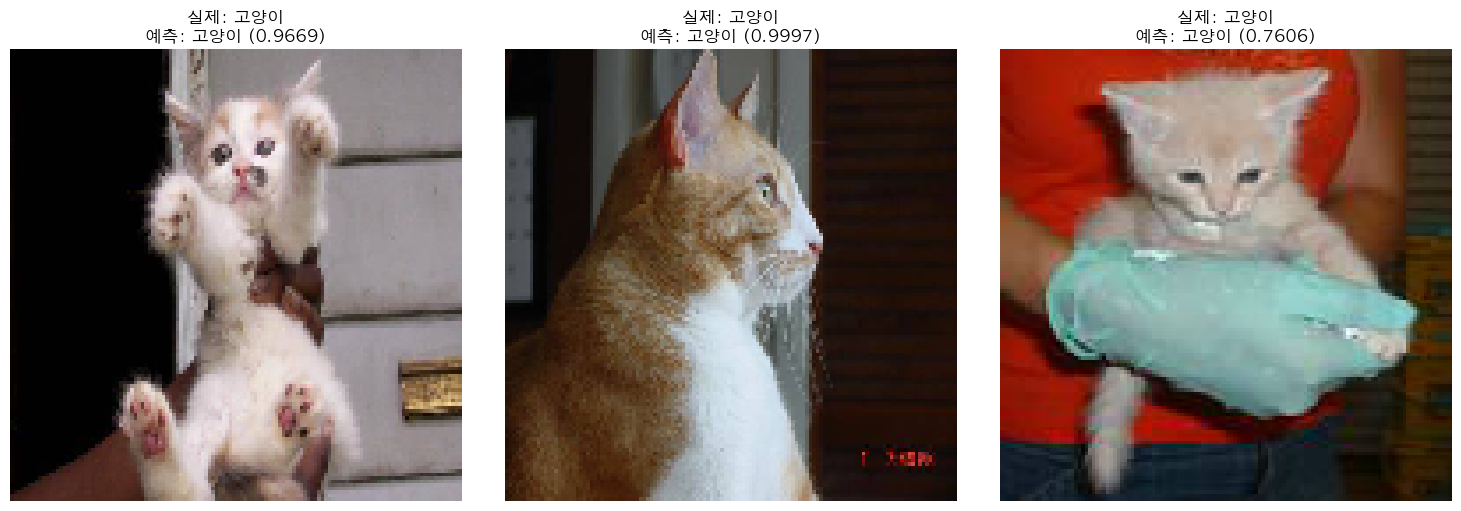

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


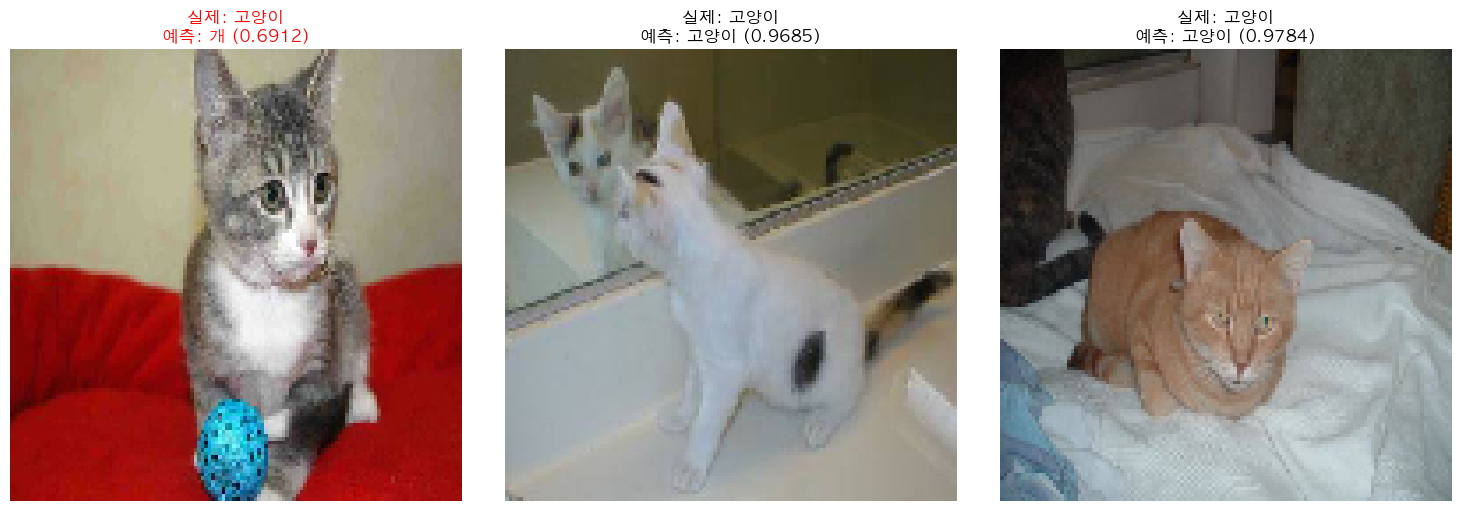

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


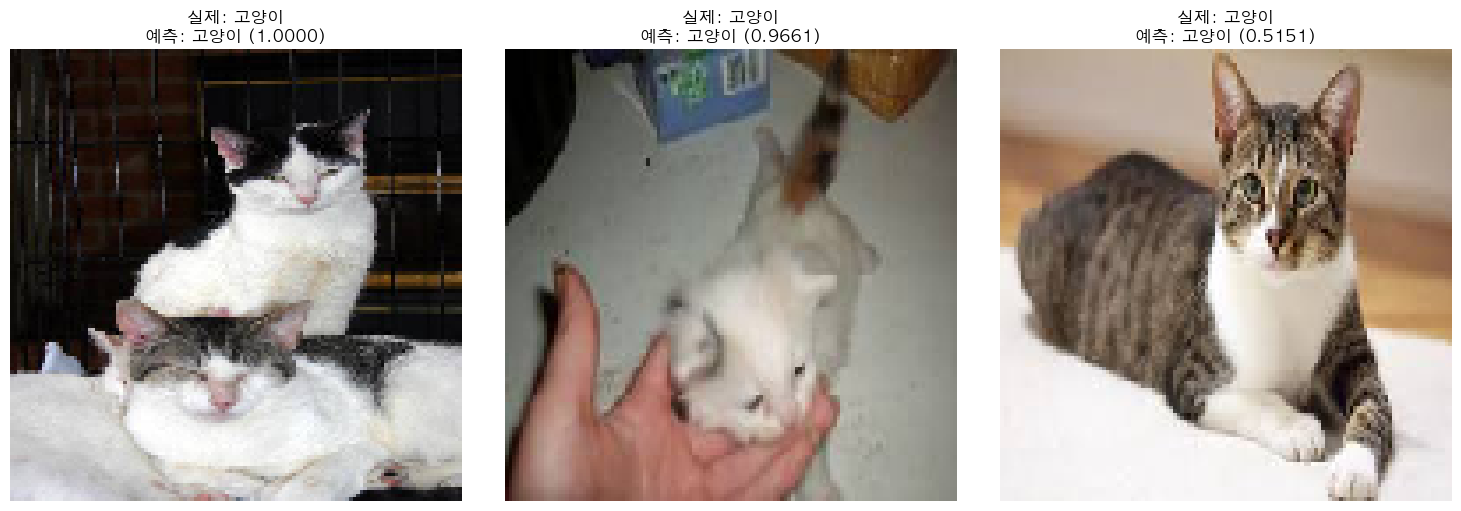

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


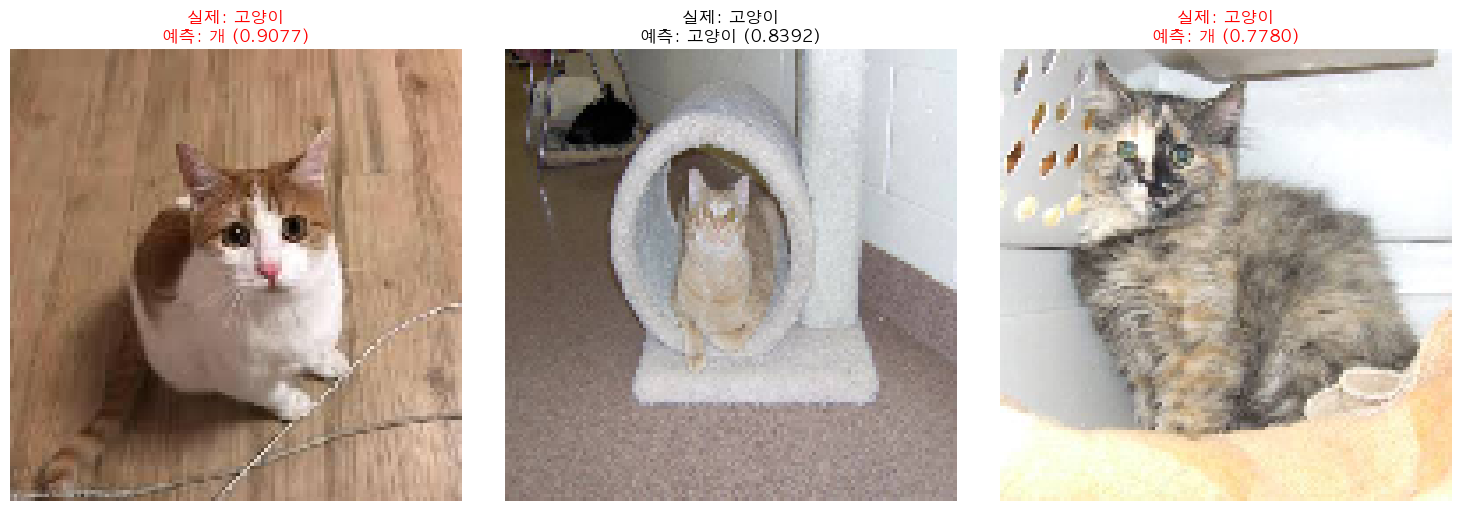

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


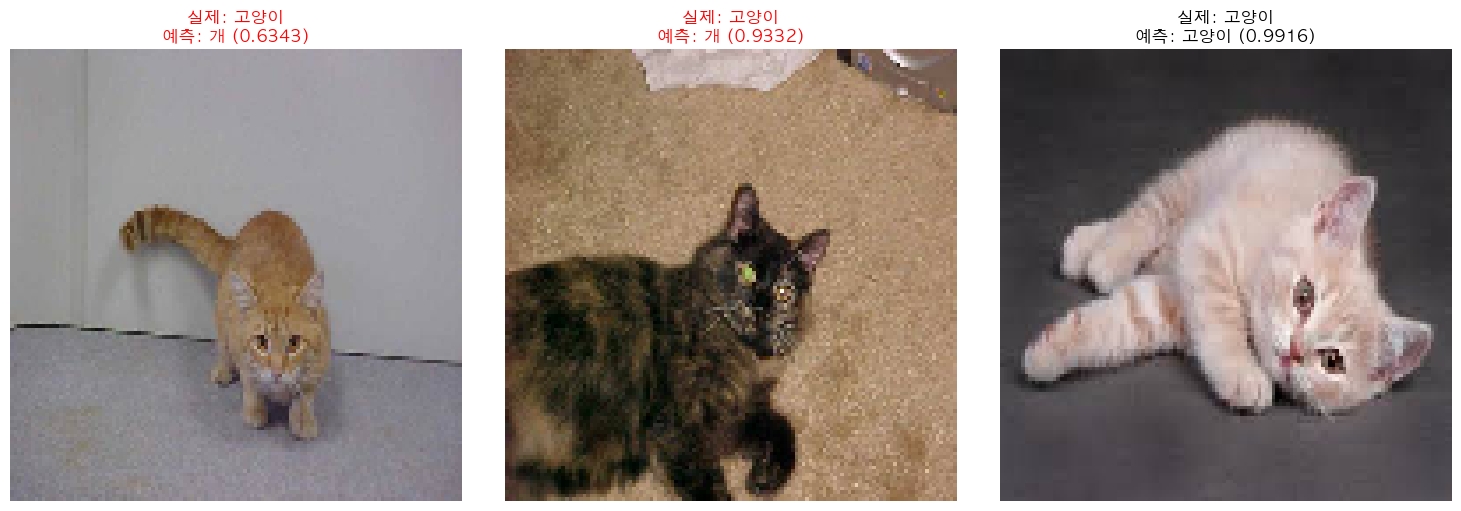

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


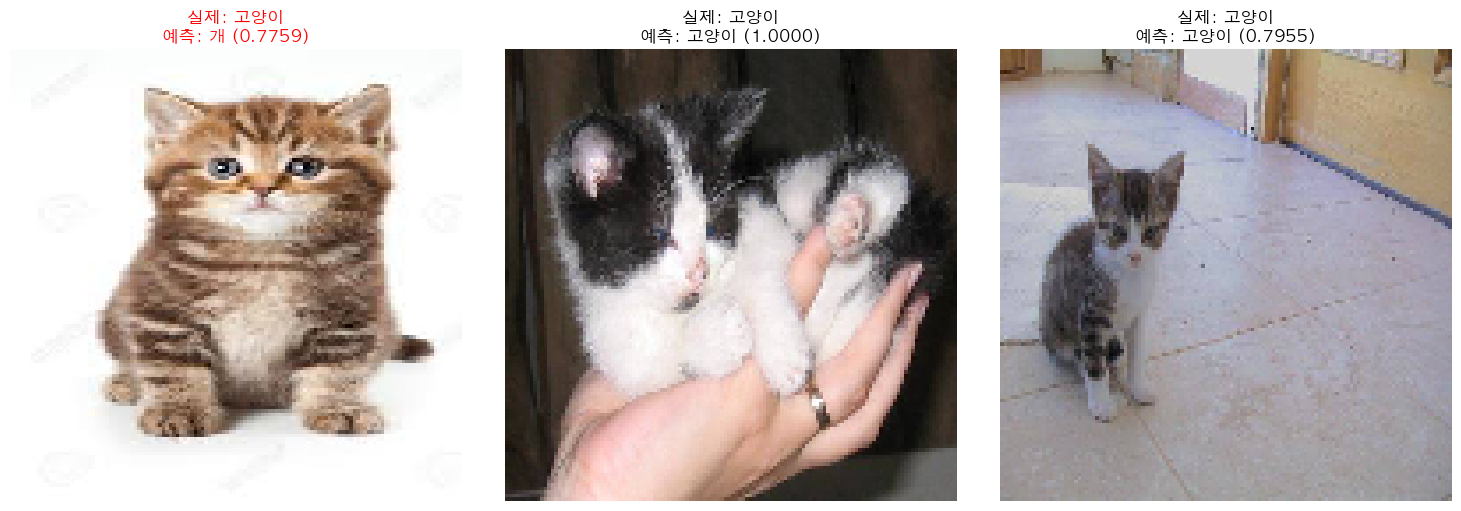

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


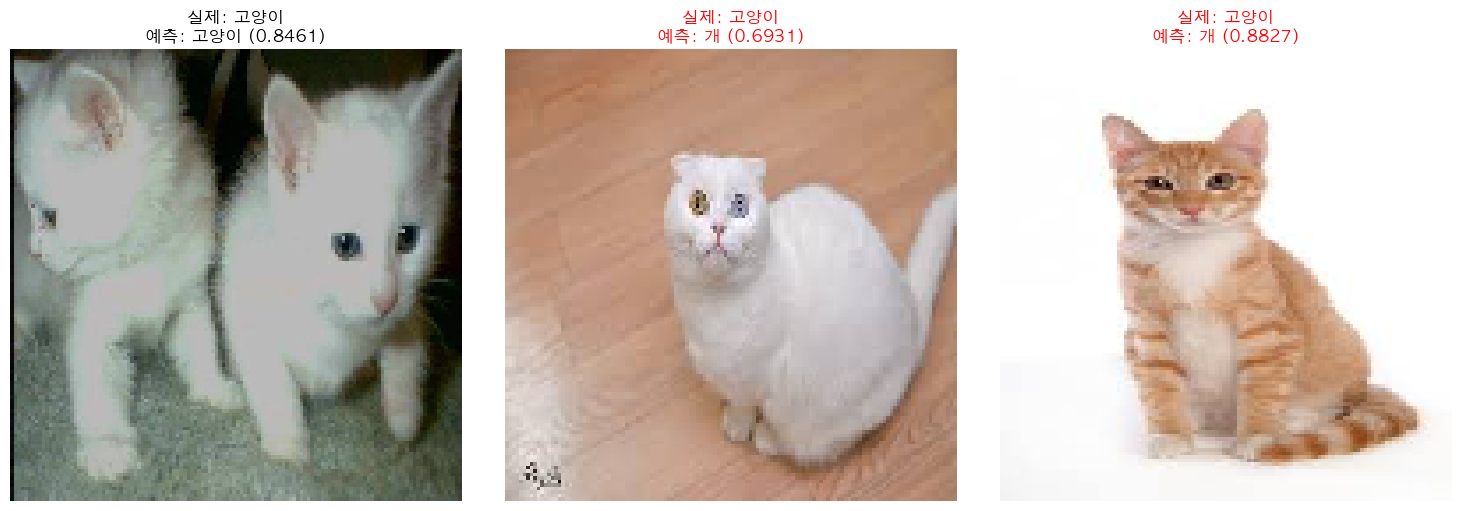

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


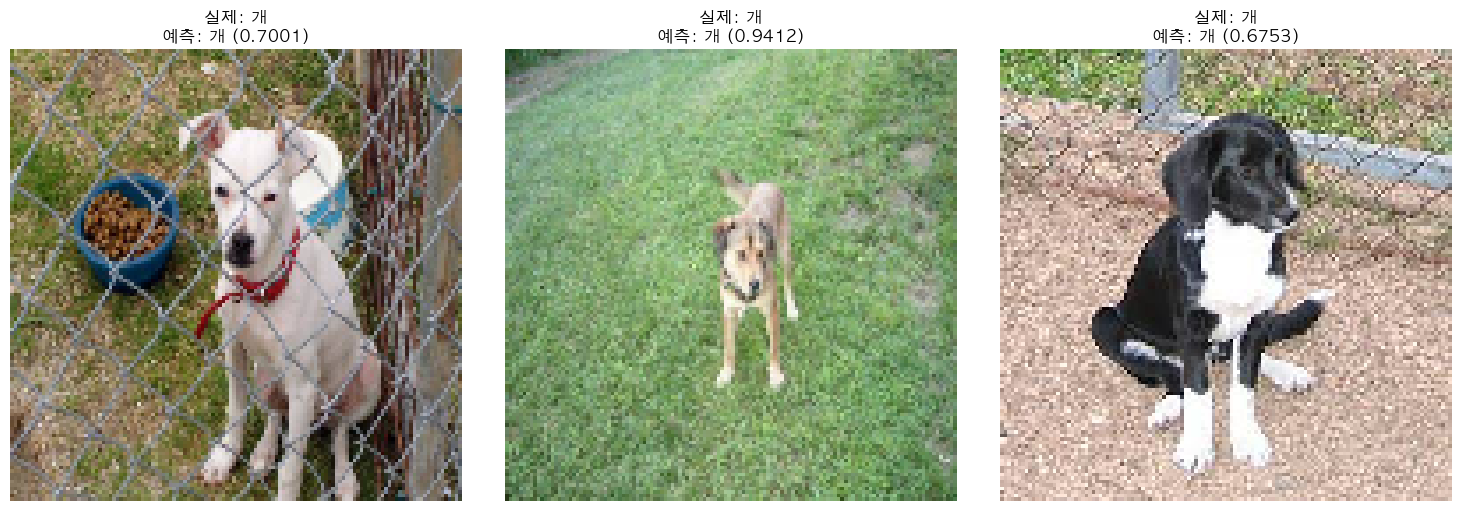

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


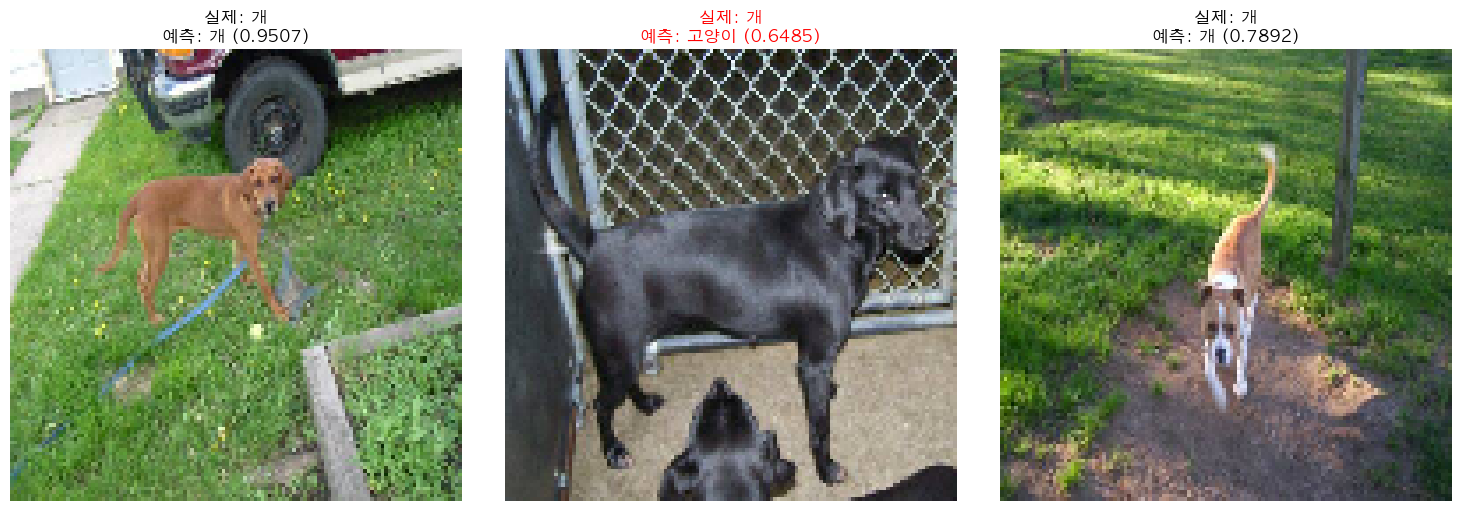

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


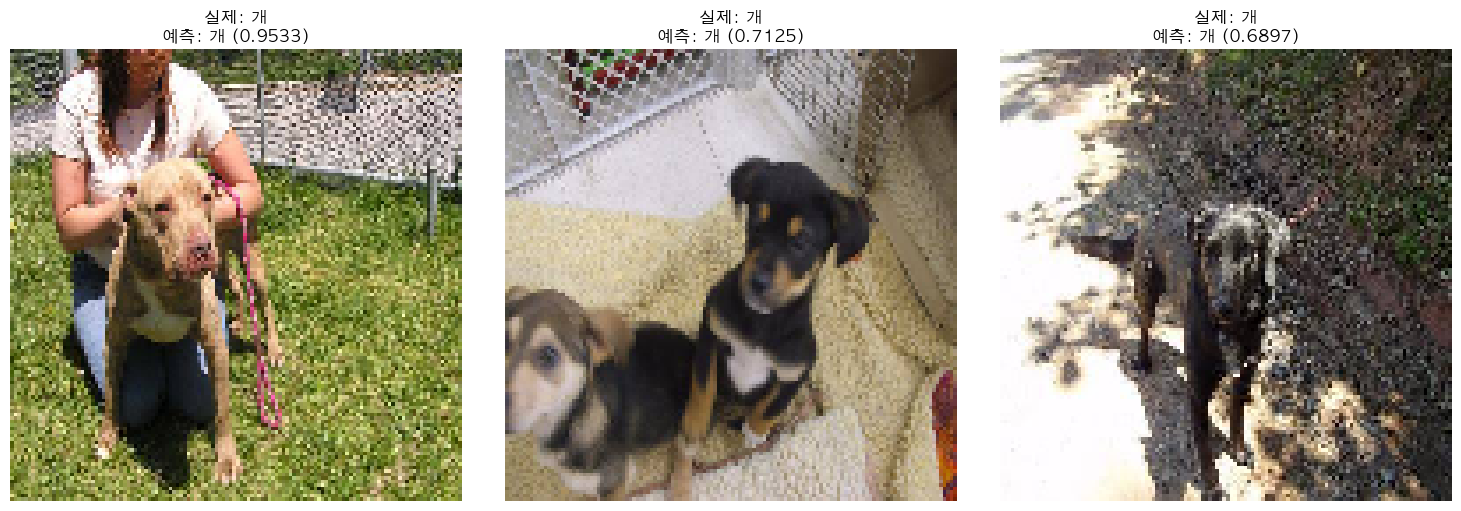

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


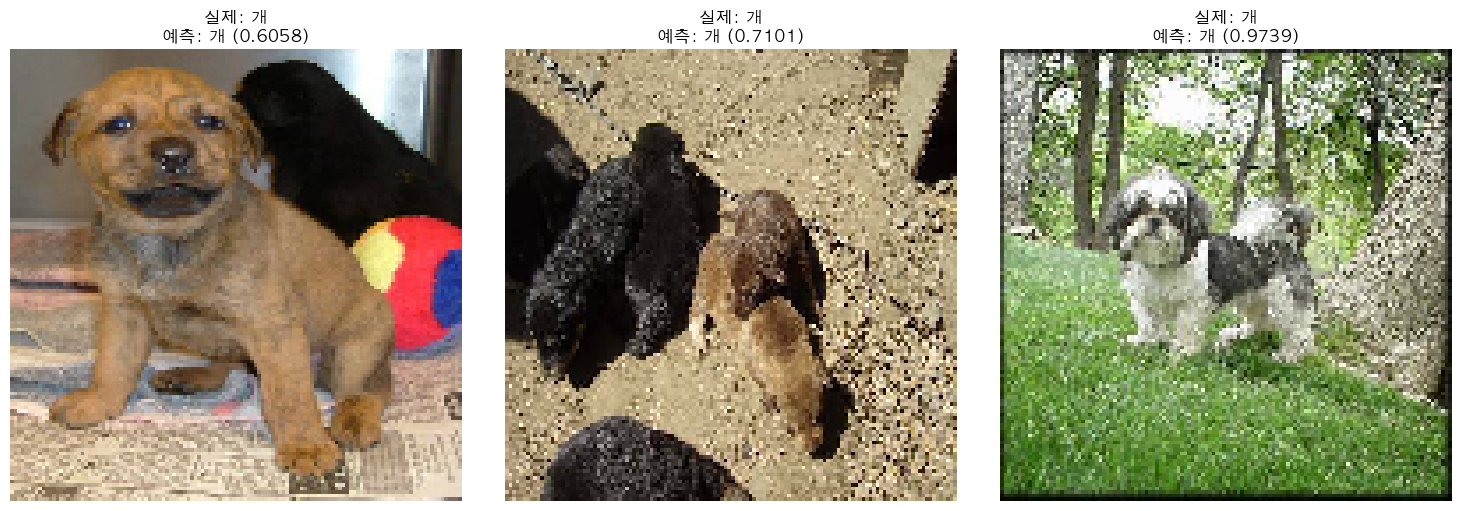

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


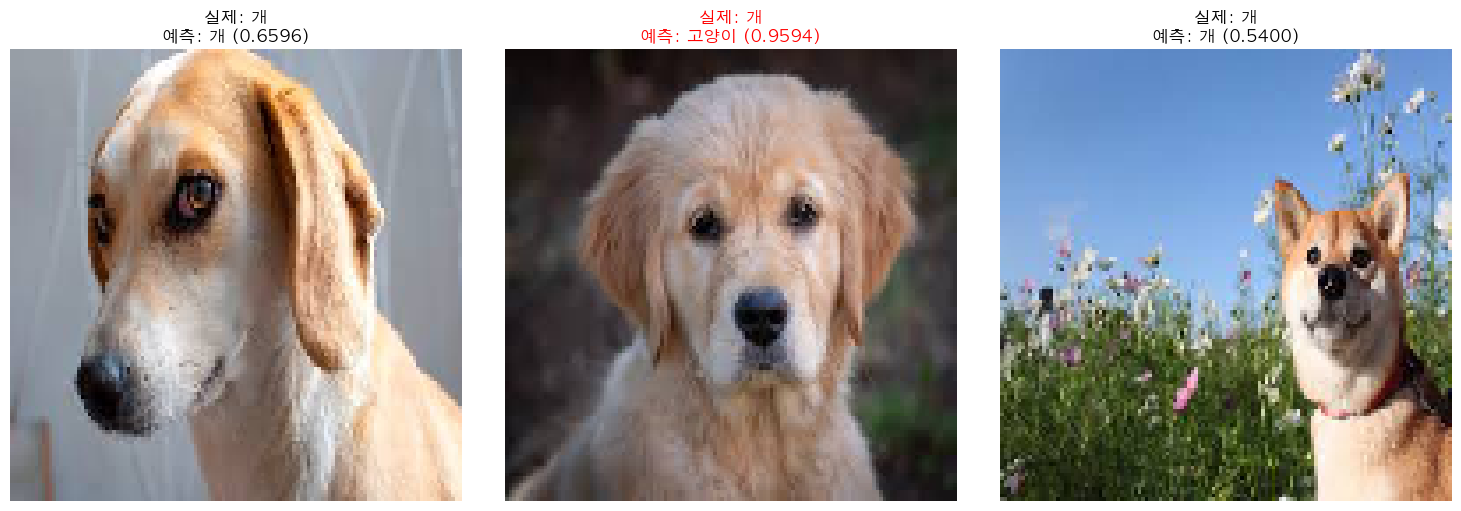

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


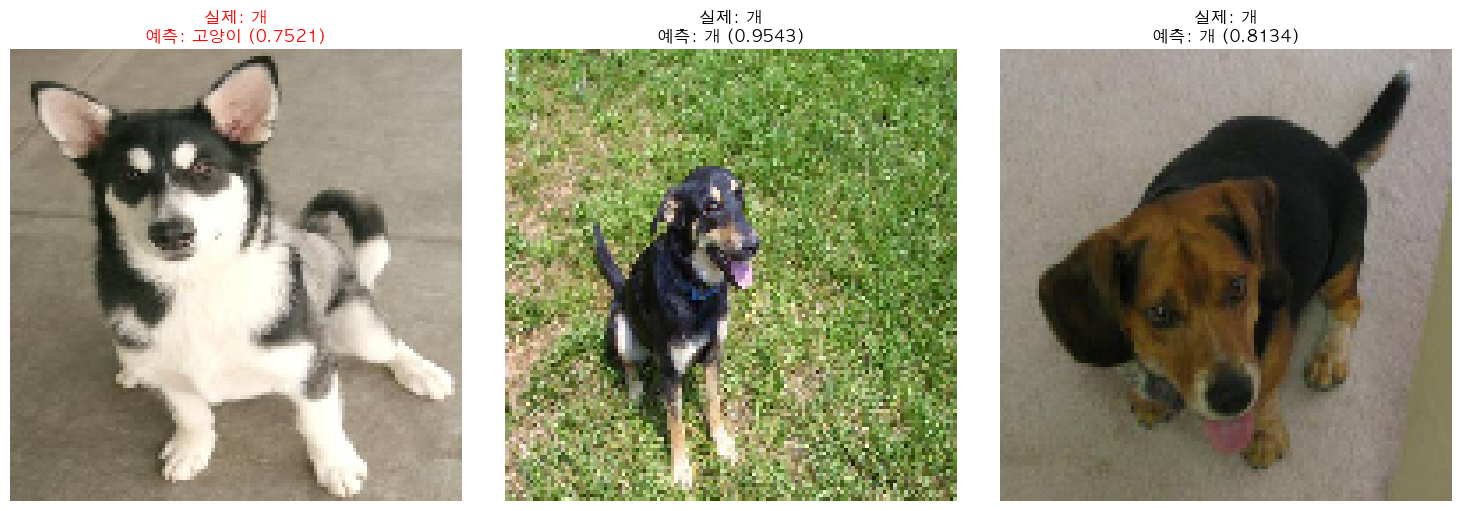

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


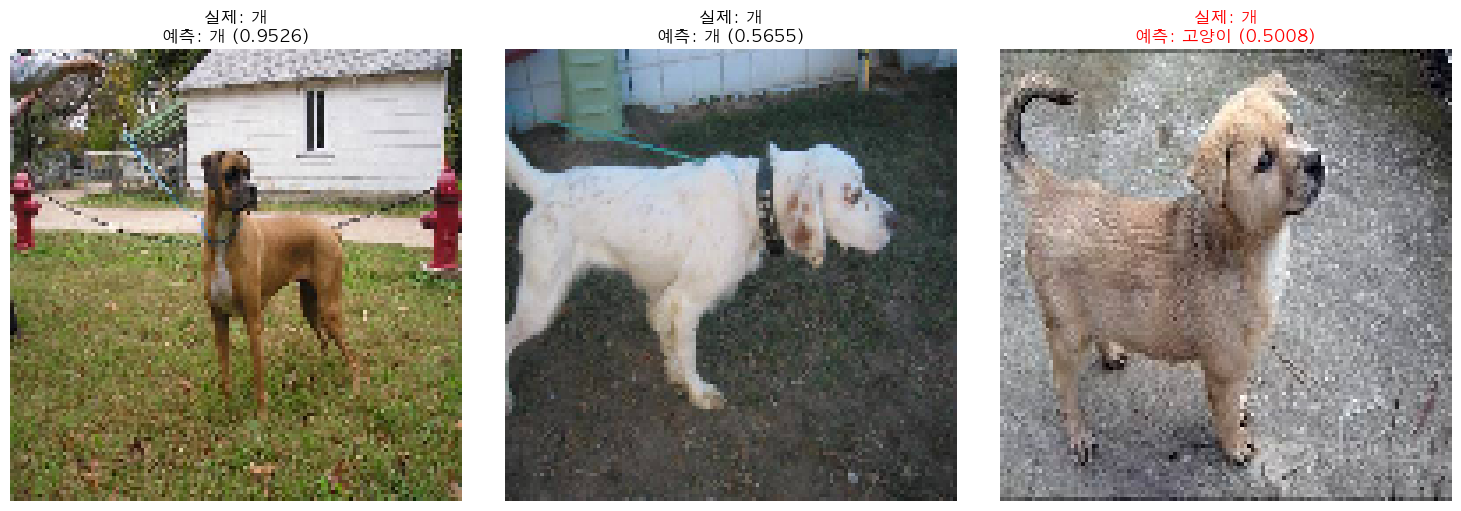

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


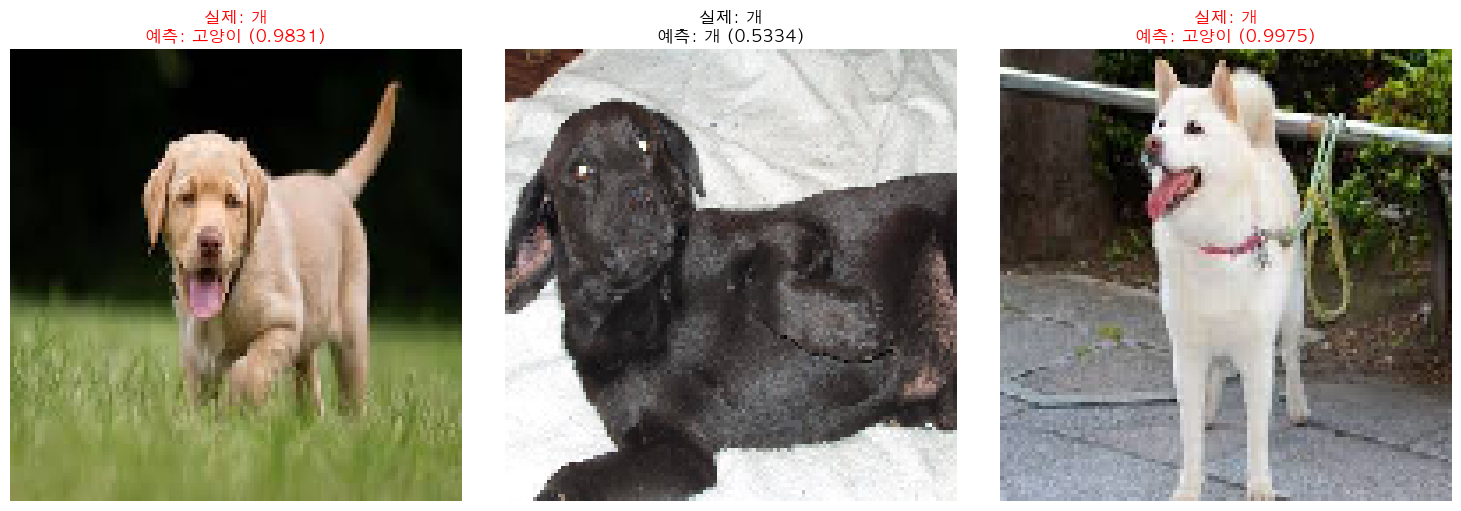

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


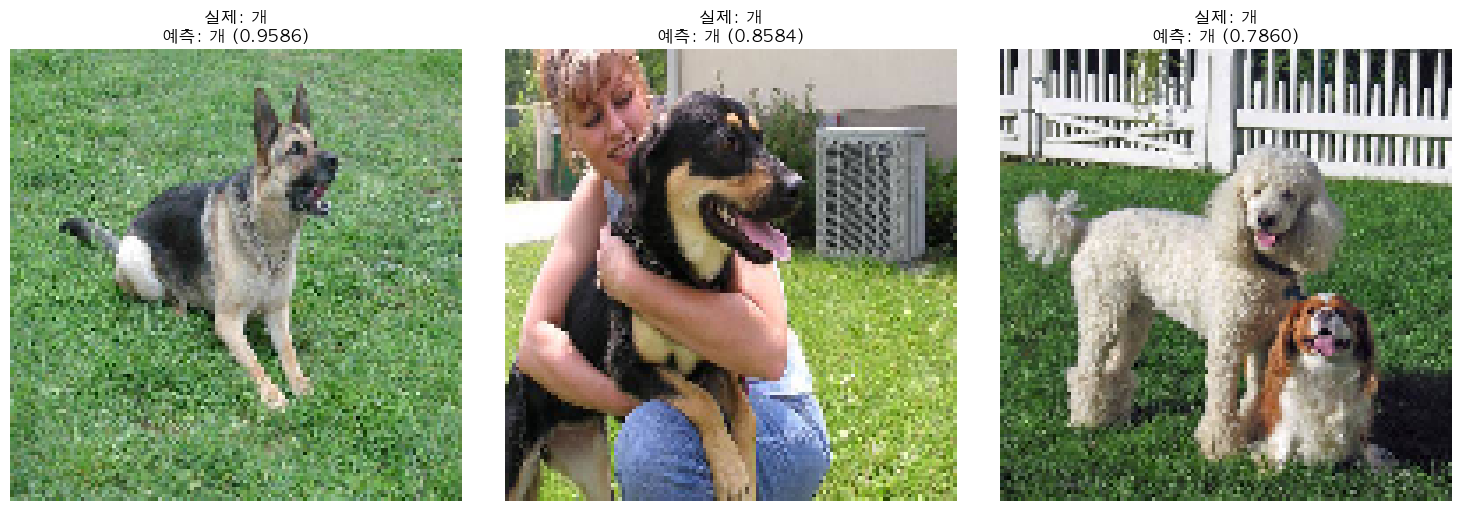

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


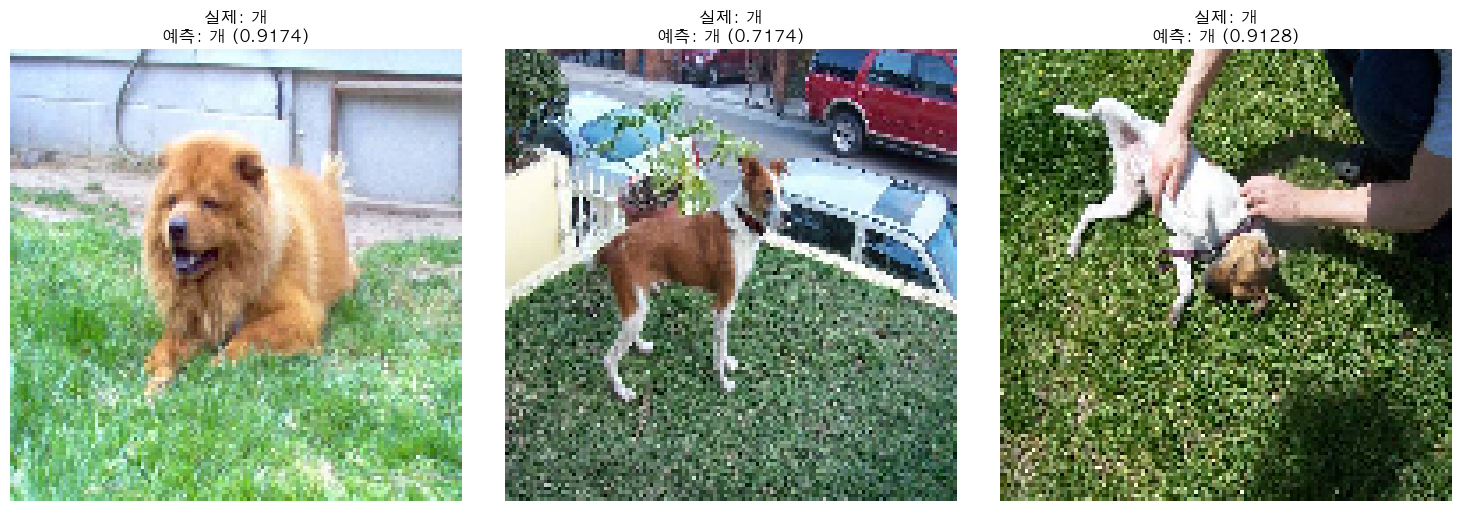


* 전체 정확도: 46/60 = 76.67%


In [6]:
import os
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, accuracy_score
# 모델 로드
model = load_model('Model_DNN_NoGen.keras')
print(f"모델 로드 완료: Model_CNN_NoGen.keras")
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.font_manager as fm
# 한글 폰트 설정
available_fonts = {font.name for font in fm.fontManager.ttflist}
for font_name in ['AppleGothic', 'Malgun Gothic', 'NanumGothic', 'Noto Sans CJK KR']:
    if font_name in available_fonts:
        plt.rcParams['font.family'] = font_name
        break
plt.rcParams['axes.unicode_minus'] = False

cls_index = ['고양이', '개']
test_num = []
rootPath = './test' #rootPath = 'E:/AIWork/Data/dogvscat/test'

# 고양이 이미지 불러오기
cat_folder = os.path.join(rootPath, 'cat')
for fname in os.listdir(cat_folder):
    if fname.lower().endswith('.jpg'):
        fpath = os.path.join(cat_folder, fname)
        img = image.load_img(fpath, target_size=(128, 128))
        test_num.append((img, 0))  # 0: 고양이

# 개 이미지 불러오기
dog_folder = os.path.join(rootPath, 'dog')
for fname in os.listdir(dog_folder):
    if fname.lower().endswith('.jpg'):
        fpath = os.path.join(dog_folder, fname)
        img = image.load_img(fpath, target_size=(128, 128))
        test_num.append((img, 1))  # 1: 개

# 예측 및 정확도 계산
correct = 0
cols = 3

for idx in range(0, len(test_num), cols):
    batch = test_num[idx:idx + cols]
    fig, axes = plt.subplots(1, len(batch), figsize=(15, 5))
    #axes가 리스트가 아니더라도 리스트처럼 axes[i] 형태로 반복 가능하게 만듦
    if len(batch) == 1:
        axes = [axes]

    for i, (img, true_label) in enumerate(batch):
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0
        img_array = img_array.reshape(1, -1)  # DNN 입력 형식으로 변환

        result = model.predict(img_array)[0][0]
        pred_label = 1 if result >= 0.5 else 0
        pred_name = '개' if pred_label == 1 else '고양이'
        prob = result if pred_label == 1 else 1 - result
        true_name = '고양이' if true_label == 0 else '개'

        # 정확도 집계
        is_correct = (pred_label == true_label)
        if is_correct:
            correct += 1

        # 이미지 출력
        axes[i].imshow(img)
        axes[i].axis('off')
        title_color = 'black' if is_correct else 'red'
        title_text = f"실제: {true_name}" + chr(10) + f"예측: {pred_name} ({prob:.4f})"
        axes[i].set_title(title_text, fontsize=12,
                          color=title_color)

    plt.tight_layout()
    plt.show()

# 전체 정확도 출력
accuracy = correct / len(test_num) * 100
print()
print(f"* 전체 정확도: {correct}/{len(test_num)} = {accuracy:.2f}%")
